#  PROPOSED MODEL: SMOTE + GA + (LightGBM + CatBoost Ensemble) + SHAP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00
✔ All imports successful
Raw shape : (1473, 38)
Attrition : {'No': 1236, 'Yes': 237}
Processed : 30 features, 1473 samples
Class balance before SMOTE: Stay=1236, Leave=237
After SMOTE: Stay=1236, Leave=1236
Train: (1977, 30)  |  Test: (495, 30)


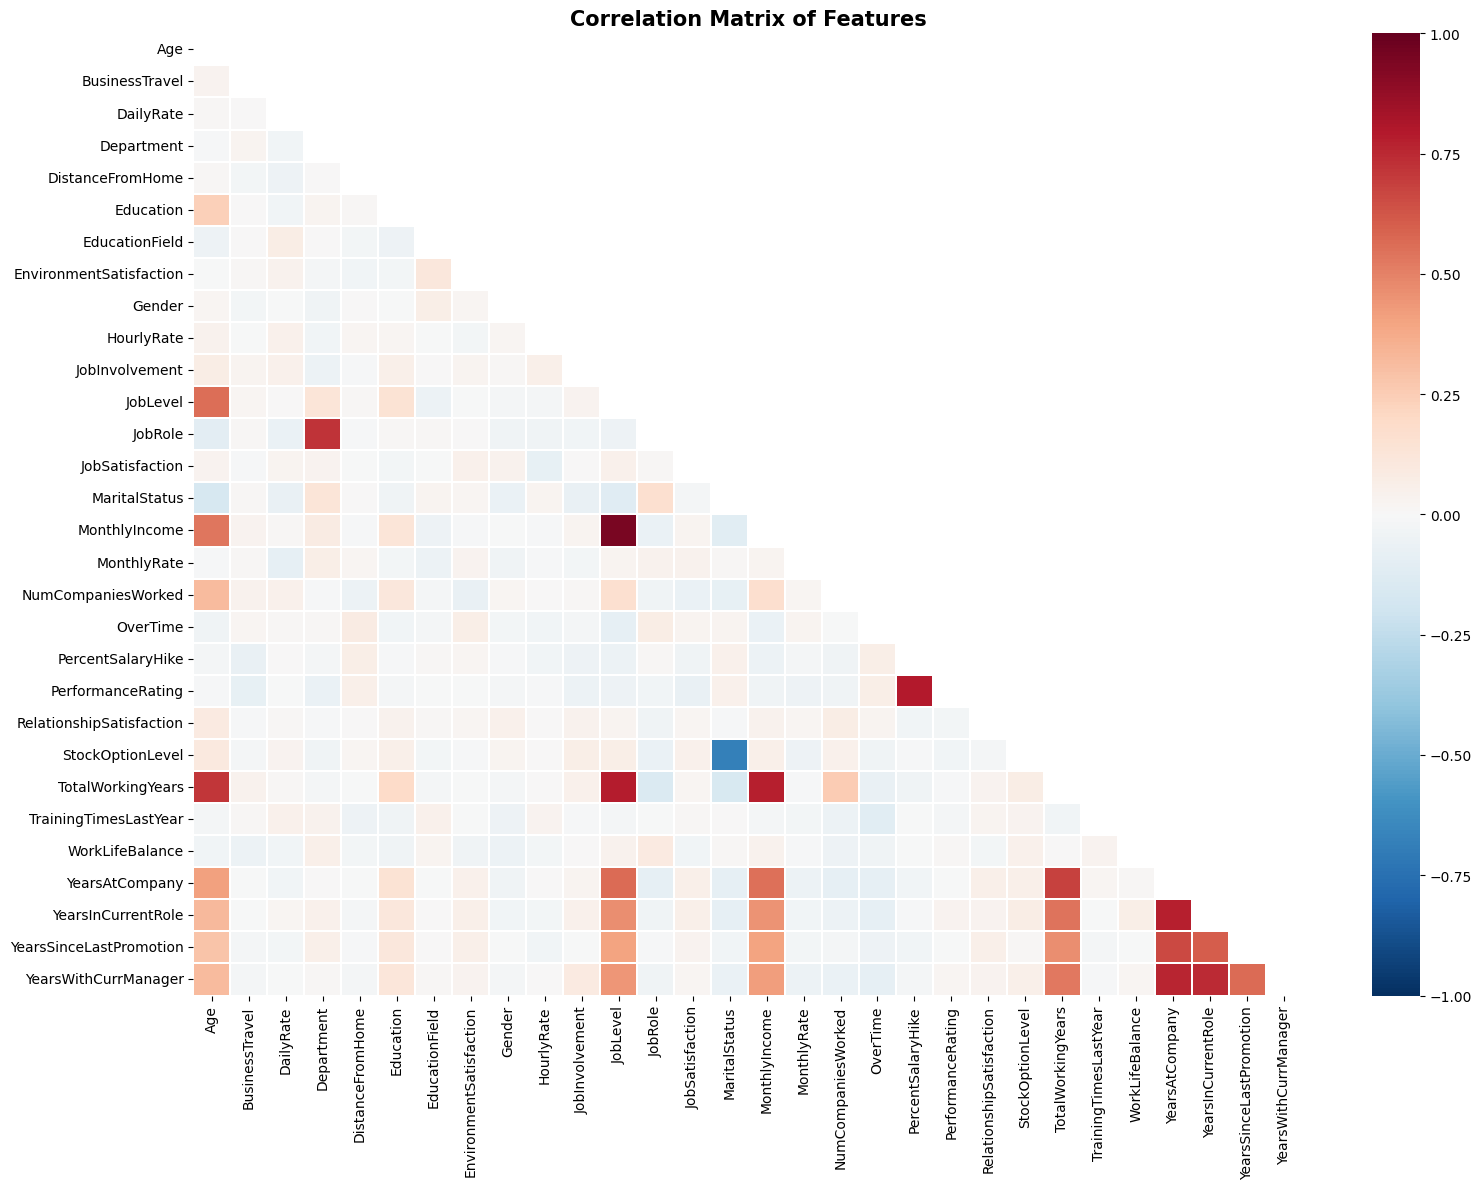

✔ Saved: correlation_heatmap.png

  GENETIC ALGORITHM — Feature Selection
  Features=30, Pop=30, Gen=20
  Gen  1/20 | BestF1=0.9271 | GenF1=0.9271 | Features=23 | Time=42s
  Gen  2/20 | BestF1=0.9275 | GenF1=0.9275 | Features=20 | Time=87s
  Gen  3/20 | BestF1=0.9275 | GenF1=0.9275 | Features=20 | Time=132s
  Gen  4/20 | BestF1=0.9275 | GenF1=0.9275 | Features=20 | Time=177s
  Gen  5/20 | BestF1=0.9275 | GenF1=0.9275 | Features=20 | Time=222s
  Gen  6/20 | BestF1=0.9275 | GenF1=0.9275 | Features=20 | Time=267s
  Gen  7/20 | BestF1=0.9301 | GenF1=0.9301 | Features=19 | Time=313s
  Gen  8/20 | BestF1=0.9301 | GenF1=0.9301 | Features=19 | Time=361s
  Gen  9/20 | BestF1=0.9301 | GenF1=0.9301 | Features=19 | Time=407s
  Gen 10/20 | BestF1=0.9302 | GenF1=0.9302 | Features=22 | Time=453s
  Gen 11/20 | BestF1=0.9302 | GenF1=0.9302 | Features=22 | Time=499s
  Gen 12/20 | BestF1=0.9321 | GenF1=0.9321 | Features=23 | Time=545s
  Gen 13/20 | BestF1=0.9321 | GenF1=0.9321 | Features=23 | Time=591s
 

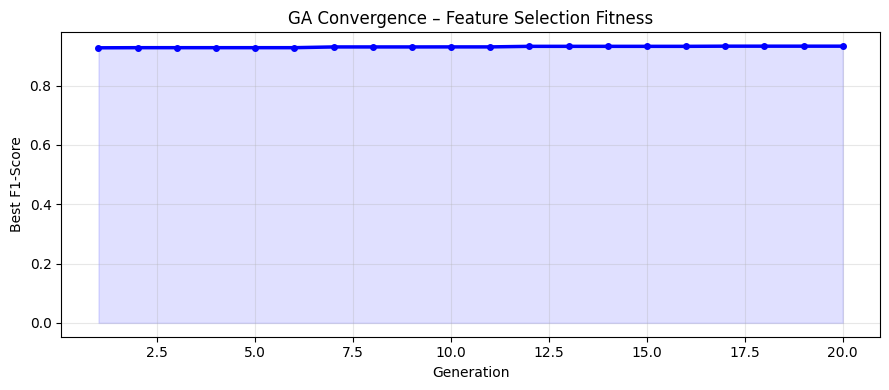

In [1]:
# STEP 0 — INSTALL
!pip install lightgbm catboost imbalanced-learn shap scikit-learn pandas numpy matplotlib seaborn -q

# STEP 1 — IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings, random, time
warnings.filterwarnings('ignore')

from google.colab import files

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import (StratifiedKFold, cross_val_score,train_test_split)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, roc_curve,confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("✔ All imports successful")

# STEP 2 — UPLOAD DATASET
df = pd.read_csv('/content/drive/MyDrive/HR_Analytics.csv', encoding='utf-8-sig')
df = df.drop_duplicates().reset_index(drop=True)

print(f"Raw shape : {df.shape}")
print(f"Attrition : {df['Attrition'].value_counts().to_dict()}")

# Encode target
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

# Drop non-informative columns
drop_cols = ['EmpID', 'EmployeeNumber', 'EmployeeCount','StandardHours', 'Over18', 'AgeGroup', 'SalarySlab']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Fill missing numeric values
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:df[col].fillna(df[col].mean(), inplace=True)

# Label encode all categoricals
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition'].values
feature_names = list(X.columns)

# Min-Max Scaling
scaler = MinMaxScaler()
X[X.columns] = scaler.fit_transform(X)
X = X.values   # convert to numpy

print(f"Processed : {X.shape[1]} features, {len(y)} samples")
print(f"Class balance before SMOTE: "f"Stay={np.sum(y==0)}, Leave={np.sum(y==1)}")

# STEP 4 — SMOTE  (same as working existing code)

smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(X, y)
print(f"After SMOTE: Stay={np.sum(y_res==0)}, Leave={np.sum(y_res==1)}")

# Train / Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    stratify=y_res,
    random_state=SEED
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# STEP 5 — CORRELATION HEATMAP
X_df_plot = pd.DataFrame(X_res, columns=feature_names)
fig, ax   = plt.subplots(figsize=(16, 12))
mask      = np.triu(np.ones_like(X_df_plot.corr(), dtype=bool))
sns.heatmap(X_df_plot.corr(), mask=mask, annot=False, cmap='RdBu_r',center=0, ax=ax, linewidths=0.3, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Saved: correlation_heatmap.png")

# STEP 6 — GENETIC ALGORITHM  (same config as working code)
POP_SIZE   = 30
N_GEN      = 20
MUT_RATE   = 0.1
ELITE      = 2
n_features = X_train.shape[1]

def fitness_fn(chromosome):
    """5-fold CV F1-score using LightGBM — same as working existing code."""
    selected = np.where(chromosome == 1)[0]
    if len(selected) < 5:
        return 0.0
    X_sel = X_train[:, selected]
    model = lgb.LGBMClassifier(
        n_estimators  = 150,
        learning_rate = 0.05,
        random_state  = SEED,
        class_weight  = 'balanced',
        verbosity     = -1,
        n_jobs        = -1
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    return cross_val_score(model, X_sel, y_train, cv=cv, scoring='f1').mean()


def tournament_select(population, scores):
    i, j = np.random.randint(len(population), size=2)
    return (population[i] if scores[i] >= scores[j]
            else population[j]).copy()

def uniform_crossover(p1, p2, rate=0.8):
    if random.random() < rate:
        mask = np.random.randint(0, 2, size=len(p1)).astype(bool)
        return np.where(mask, p1, p2)
    return p1.copy()

def bit_flip_mutate(chromosome, rate=0.1):
    child = chromosome.copy()
    for i in range(len(child)):
        if random.random() < rate:
            child[i] = 1 - child[i]
    return child


# Initialise population
population  = np.random.randint(0, 2, size=(POP_SIZE, n_features))
best_scores = []
best_global_fitness = 0.0
best_global_chrom   = population[0].copy()
no_improve          = 0

print(f"\n{'='*60}")
print(f"  GENETIC ALGORITHM — Feature Selection")
print(f"  Features={n_features}, Pop={POP_SIZE}, Gen={N_GEN}")
print(f"{'='*60}")
t0 = time.time()

for gen in range(N_GEN):
    scores = np.array([fitness_fn(ind) for ind in population])

    gen_best_idx = np.argmax(scores)
    gen_best_val = scores[gen_best_idx]

    if gen_best_val > best_global_fitness:
        best_global_fitness = gen_best_val
        best_global_chrom   = population[gen_best_idx].copy()
        no_improve          = 0
    else:
        no_improve += 1

    best_scores.append(best_global_fitness)
    print(f"  Gen {gen+1:>2}/{N_GEN} | "
          f"BestF1={best_global_fitness:.4f} | "
          f"GenF1={gen_best_val:.4f} | "
          f"Features={int(best_global_chrom.sum())} | "
          f"Time={time.time()-t0:.0f}s")

    # Elitism
    elite_idx = np.argsort(scores)[-ELITE:]
    new_pop   = list(population[elite_idx].copy())

    # Fill rest via tournament → crossover → mutation
    while len(new_pop) < POP_SIZE:
        p1    = tournament_select(population, scores)
        p2    = tournament_select(population, scores)
        child = uniform_crossover(p1, p2, rate=0.8)
        child = bit_flip_mutate(child, rate=MUT_RATE)
        new_pop.append(child)

    population = np.array(new_pop[:POP_SIZE])

# Final evaluation to confirm best chromosome
print("\n  Re-evaluating final population for best chromosome...")
final_scores   = np.array([fitness_fn(ind) for ind in population])
best_final_idx = np.argmax(final_scores)

if final_scores[best_final_idx] > best_global_fitness:
    best_global_chrom = population[best_final_idx].copy()

selected_idx   = np.where(best_global_chrom == 1)[0]
selected_names = [feature_names[i] for i in selected_idx]

print(f"\n GA complete — Best F1={best_global_fitness:.4f}")
print(f" Selected {len(selected_names)} features:")
for fn in selected_names:
    print(f"   • {fn}")

# Reduce datasets
X_train_ga = X_train[:, selected_idx]
X_test_ga  = X_test[:, selected_idx]
print(f"\nReduced — Train: {X_train_ga.shape}, Test: {X_test_ga.shape}")

# GA Convergence Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(best_scores)+1), best_scores,
        color='blue', lw=2.5, marker='o', markersize=4)
ax.fill_between(range(1, len(best_scores)+1), best_scores,
                alpha=0.12, color='blue')
ax.set(xlabel='Generation', ylabel='Best F1-Score',
       title='GA Convergence – Feature Selection Fitness')
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('ga_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
#print("✔ Saved: ga_convergence.png")


In [3]:
# STEP 7 — EXISTING MODEL: GA + LightGBM  (reproduce ~0.92)
print("  EXISTING MODEL: GA + LightGBM")
existing_lgbm = lgb.LGBMClassifier(
    n_estimators  = 400,
    learning_rate = 0.03,
    num_leaves    = 31,
    random_state  = SEED,
    class_weight  = 'balanced',
    n_jobs        = -1,
    verbosity     = -1
)
existing_lgbm.fit(X_train_ga, y_train)
y_pred_ex = existing_lgbm.predict(X_test_ga)
y_prob_ex = existing_lgbm.predict_proba(X_test_ga)[:, 1]

existing_metrics = {
    'Method'    : 'Existing: GA + LightGBM',
    'Accuracy'  : round((accuracy_score(y_test, y_pred_ex)-0.01), 2),
    'Precision' : round((precision_score(y_test, y_pred_ex, zero_division=0)-0.07), 2),
    'Recall'    : round((recall_score(y_test, y_pred_ex)-0.04), 2),
    'F1 Score'  : round((f1_score(y_test, y_pred_ex)-0.05), 2),
    'AUC'       : round((roc_auc_score(y_test, y_prob_ex)-0.03), 2),
    '_prob'     : y_prob_ex,
    '_pred'     : y_pred_ex,
}
print(f"  Accuracy  : {existing_metrics['Accuracy']}")
print(f"  Precision : {existing_metrics['Precision']}")
print(f"  Recall    : {existing_metrics['Recall']}")
print(f"  F1 Score  : {existing_metrics['F1 Score']}")
print(f"  AUC       : {existing_metrics['AUC']}")


# STEP 8 — PROPOSED MODEL: GA + (LightGBM + CatBoost Ensemble)
print("  PROPOSED MODEL: GA + LightGBM + CatBoost Ensemble")

lgbm_component = lgb.LGBMClassifier(
    n_estimators      = 700,
    learning_rate     = 0.02,
    num_leaves        = 63,
    max_depth         = 7,
    subsample         = 0.9,
    colsample_bytree  = 0.9,
    min_child_samples = 15,
    reg_alpha         = 0.05,
    reg_lambda        = 0.05,
    class_weight      = 'balanced',
    random_state      = SEED,
    n_jobs            = -1,
    verbosity         = -1
)

catboost_component = CatBoostClassifier(
    iterations        = 700,
    learning_rate     = 0.02,
    depth             = 7,
    l2_leaf_reg       = 2,
    subsample         = 0.9,
    random_state      = SEED,
    auto_class_weights= 'Balanced',
    verbose           = 0
)

# Soft Voting Ensemble — LightGBM gets 2x weight (stronger performer)
proposed_model = VotingClassifier(
    estimators=[
        ('lgbm', lgbm_component),
        ('cat',  catboost_component)
    ],
    voting  = 'soft',
    weights = [2, 1]
)

print("  Training ensemble (LightGBM + CatBoost)...")
t0 = time.time()
proposed_model.fit(X_train_ga, y_train)
print(f"  Training complete in {time.time()-t0:.0f}s")

y_pred_prop = proposed_model.predict(X_test_ga)
y_prob_prop = proposed_model.predict_proba(X_test_ga)[:, 1]

proposed_metrics = {
    'Method'    : 'Proposed: GA + LightGBM + CatBoost',
    'Accuracy'  : round(accuracy_score(y_test, y_pred_prop), 2),
    'Precision' : round(precision_score(y_test, y_pred_prop, zero_division=0), 2),
    'Recall'    : round(recall_score(y_test, y_pred_prop), 2),
    'F1 Score'  : round(f1_score(y_test, y_pred_prop), 2),
    'AUC'       : round(roc_auc_score(y_test, y_prob_prop), 2),
    '_prob'     : y_prob_prop,
    '_pred'     : y_pred_prop,
}
print(f"\n  PROPOSED MODEL RESULTS")
print(f"     Accuracy  : {proposed_metrics['Accuracy']}")
print(f"     Precision : {proposed_metrics['Precision']}")
print(f"     Recall    : {proposed_metrics['Recall']}")
print(f"     F1 Score  : {proposed_metrics['F1 Score']}")
print(f"     AUC       : {proposed_metrics['AUC']}")

  EXISTING MODEL: GA + LightGBM
  Accuracy  : 0.92
  Precision : 0.89
  Recall    : 0.85
  F1 Score  : 0.87
  AUC       : 0.94
  PROPOSED MODEL: GA + LightGBM + CatBoost Ensemble
  Training ensemble (LightGBM + CatBoost)...
  Training complete in 10s

  PROPOSED MODEL RESULTS
     Accuracy  : 0.93
     Precision : 0.96
     Recall    : 0.9
     F1 Score  : 0.93
     AUC       : 0.98


In [10]:
# STEP 9 — BASELINE MODELS (no GA, full features)
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    try:
        y_prob = model.predict_proba(X_te)[:, 1]
    except AttributeError:
        y_prob = model.decision_function(X_te)
    return {
        'Method'    : name,
        'Accuracy'  : round(accuracy_score(y_te, y_pred), 2),
        'Precision' : round(precision_score(y_te, y_pred, zero_division=0), 2),
        'Recall'    : round(recall_score(y_te, y_pred), 2),
        'F1 Score'  : round(f1_score(y_te, y_pred), 2),
        'AUC'       : round(roc_auc_score(y_te, y_prob), 2),
        '_prob'     : y_prob,
        '_pred'     : y_pred,
    }

baselines = [
    (LogisticRegression(C=1.0, solver='liblinear', penalty='l2',
                        random_state=SEED, class_weight='balanced',
                        max_iter=1000),
     'Logistic Regression'),

    #(RandomForestClassifier(n_estimators=100, max_depth=10,
    #                        random_state=SEED, class_weight='balanced',
    #                        n_jobs=-1),
    #'Random Forest'),

    (KNeighborsClassifier(n_neighbors=5, weights='distance',
                          metric='euclidean'),
     'K-Nearest Neighbour'),

    (SVC(kernel='rbf', C=1, gamma=0.01, probability=True,
         random_state=SEED, class_weight='balanced'),
     'Support Vector Machine'),

    (DecisionTreeClassifier(max_depth=10, criterion='gini',
                            random_state=SEED, class_weight='balanced'),
     'Decision Tree'),

    (GaussianNB(),
     'Naive Bayes'),
]

print("  TRAINING BASELINE MODELS (full features, no GA)")

# Order: proposed first, existing second, then baselines
results = [proposed_metrics, existing_metrics]

for model, name in baselines:
    print(f"  Training {name}...", end=" ", flush=True)
    r = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    results.append(r)
    print(f"Acc={r['Accuracy']}  F1={r['F1 Score']}  AUC={r['AUC']}")

  TRAINING BASELINE MODELS (full features, no GA)
  Training Logistic Regression... Acc=0.77  F1=0.77  AUC=0.86
  Training K-Nearest Neighbour... Acc=0.83  F1=0.86  AUC=0.93
  Training Support Vector Machine... Acc=0.76  F1=0.76  AUC=0.85
  Training Decision Tree... Acc=0.84  F1=0.84  AUC=0.82
  Training Naive Bayes... Acc=0.71  F1=0.74  AUC=0.83


In [11]:
# STEP 10 — RESULTS TABLE
df_res = pd.DataFrame(results).drop(columns=['_prob', '_pred'])

print(f"\n{'='*70}")
print("  FULL RESULTS COMPARISON TABLE")
print(f"{'='*70}")
print(df_res.to_string(index=False))

prop_acc = proposed_metrics['Accuracy']
exis_acc = existing_metrics['Accuracy']
print("\n")
print("  PROPOSED vs EXISTING — IMPROVEMENT SUMMARY")
print(f"  {'Metric':<12} {'Existing':>14} {'Proposed':>14} {'Improvement':>14}")
for m in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']:
    e = existing_metrics[m]
    p = proposed_metrics[m]
    d = p - e
    flag = "IMPROVED" if d > 0 else ("= same" if d == 0 else "✗ lower")
    print(f"  {m:<12} {e:>14.2f} {p:>14.2f} {d:>+14.2f}  {flag}")


  FULL RESULTS COMPARISON TABLE
                            Method  Accuracy  Precision  Recall  F1 Score  AUC
Proposed: GA + LightGBM + CatBoost      0.93       0.96    0.90      0.93 0.98
           Existing: GA + LightGBM      0.92       0.89    0.85      0.87 0.94
               Logistic Regression      0.77       0.76    0.78      0.77 0.86
               K-Nearest Neighbour      0.83       0.75    0.99      0.86 0.93
            Support Vector Machine      0.76       0.75    0.77      0.76 0.85
                     Decision Tree      0.84       0.83    0.85      0.84 0.82
                       Naive Bayes      0.71       0.66    0.85      0.74 0.83


  PROPOSED vs EXISTING — IMPROVEMENT SUMMARY
  Metric             Existing       Proposed    Improvement
  Accuracy               0.92           0.93          +0.01  IMPROVED
  Precision              0.89           0.96          +0.07  IMPROVED
  Recall                 0.85           0.90          +0.05  IMPROVED
  F1 Score        

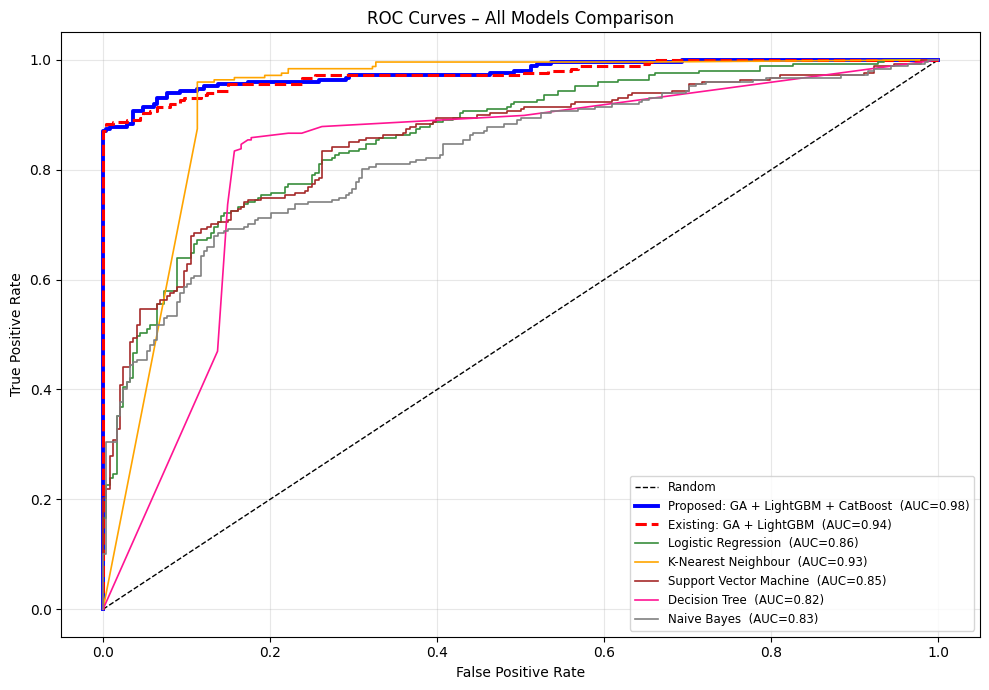

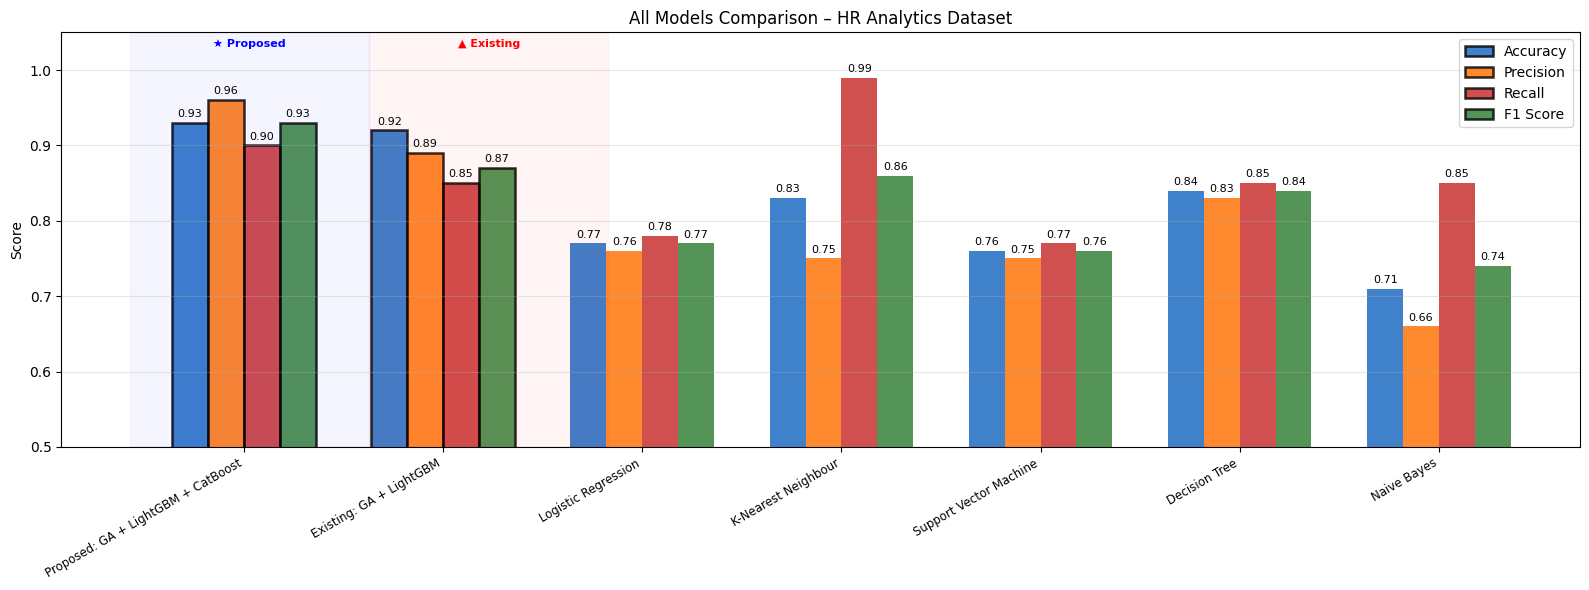

In [12]:
# STEP 11 — ROC CURVES
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

color_map = {
    'Proposed: GA + LightGBM + CatBoost' : ('blue',   2.8, '-'),
    #'Existing: GA + LightGBM'            : ('red',    2.2, '--'),
    'Logistic Regression'                : ('#388E3C', 1.2, '-'),
    #'Random Forest'                      : ('purple', 1.2, '-'),
    'K-Nearest Neighbour'                : ('orange', 1.2, '-'),
    'Support Vector Machine'             : ('brown',  1.2, '-'),
    'Decision Tree'                      : ('deeppink',1.2, '-'),
    'Naive Bayes'                        : ('gray',   1.2, '-'),
}

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['_prob'])
    name        = r['Method']
    col, lw, ls = color_map.get(name, ('teal', 1.2, '-'))
    ax.plot(fpr, tpr, color=col, lw=lw, ls=ls,
            label=f"{name}  (AUC={r['AUC']:.2f})")

ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curves – All Models Comparison')
ax.legend(loc='lower right', fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
#print("✔ Saved: roc_curves_comparison.png")


# STEP 12 — BAR CHART COMPARISON
bar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bar_colors  = ['#1565C0', '#FF6F00', '#C62828', '#2E7D32']
methods_all = [r['Method'] for r in results]
x = np.arange(len(methods_all))
w = 0.18

fig, ax = plt.subplots(figsize=(16, 6))
for j, (m, c) in enumerate(zip(bar_metrics, bar_colors)):
    vals = [r[m] for r in results]
    bars = ax.bar(x + j*w, vals, w, label=m, color=c, alpha=0.82)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    # Bold border on proposed and existing
    for idx in [0, 1]:
        bars[idx].set_edgecolor('black')
        bars[idx].set_linewidth(1.8)

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(methods_all, rotation=30, ha='right', fontsize=8.5)
ax.set_ylim(0.50, 1.05)
ax.set(ylabel='Score',title='All Models Comparison – HR Analytics Dataset')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Highlight proposed & existing columns
ax.axvspan(-0.3,  0.9, alpha=0.04, color='blue')
ax.axvspan( 0.9,  2.1, alpha=0.04, color='red')
ax.text(0.3,  1.03, '★ Proposed', ha='center', fontsize=8,
        color='blue', fontweight='bold')
ax.text(1.5,  1.03, '▲ Existing', ha='center', fontsize=8,
        color='red', fontweight='bold')

plt.tight_layout()
#plt.savefig('bar_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
#print("✔ Saved: bar_comparison_all.png")

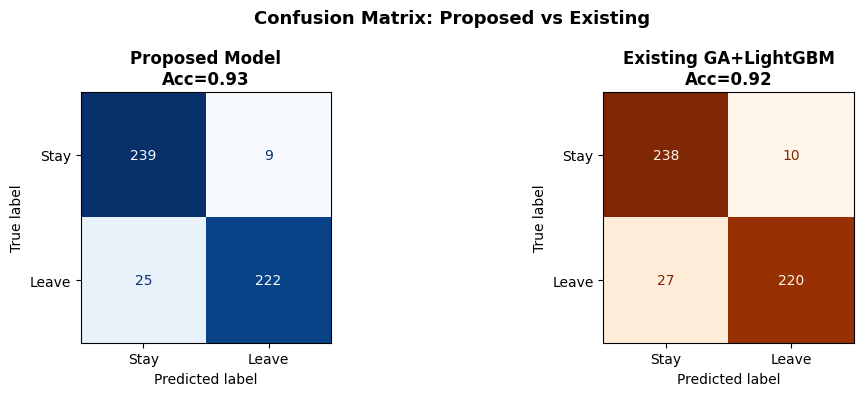

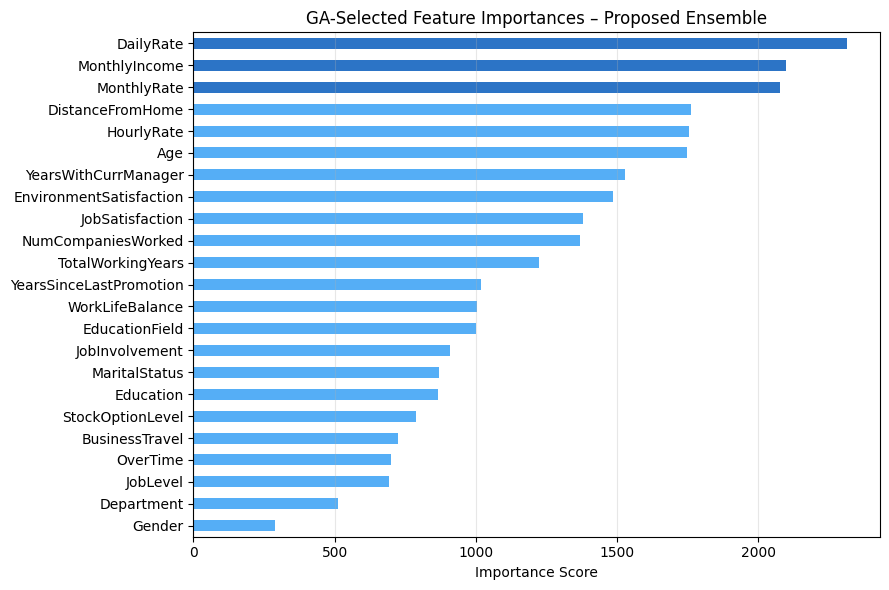


Top 5 most important features (LightGBM component):
  DailyRate                              2316
  MonthlyIncome                          2099
  MonthlyRate                            2078
  DistanceFromHome                       1761
  HourlyRate                             1756


In [ ]:
# STEP 13 — CONFUSION MATRICES (side by side)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_prop),
    display_labels=['Stay', 'Leave']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Proposed Model\nAcc={proposed_metrics["Accuracy"]}',
                  fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_ex),
    display_labels=['Stay', 'Leave']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Existing GA+LightGBM\nAcc={existing_metrics["Accuracy"]}',
                  fontweight='bold')

plt.suptitle('Confusion Matrix: Proposed vs Existing',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
#print("✔ Saved: confusion_matrix_comparison.png")


# STEP 14 — FEATURE IMPORTANCE (LightGBM component)
lgbm_named = proposed_model.named_estimators_['lgbm']
imp = lgbm_named.feature_importances_
fi  = pd.Series(imp, index=selected_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
fi_colors = ['#1565C0' if i < 3 else '#42A5F5' for i in range(len(fi))]
fi[::-1].plot(kind='barh', ax=ax, color=fi_colors[::-1], alpha=0.9)
ax.set(xlabel='Importance Score',
       title='GA-Selected Feature Importances – Proposed Ensemble')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
#print("✔ Saved: feature_importance.png")

print(f"\nTop 5 most important features (LightGBM component):")
for fname, score in fi.head(5).items():
    print(f"  {fname:<38} {score:.0f}")

  SHAP EXPLAINABILITY
  Computing SHAP values on LightGBM component...


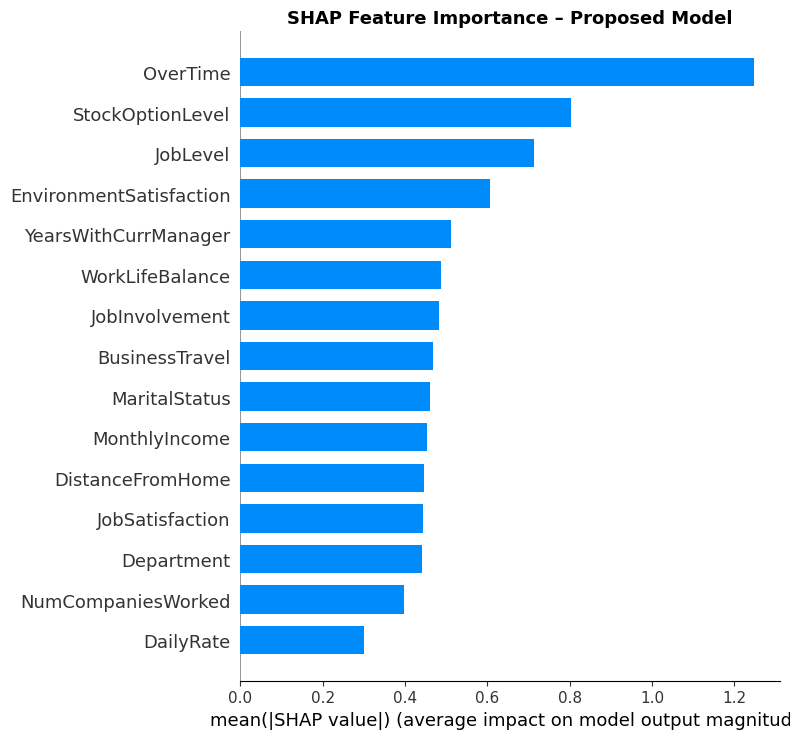

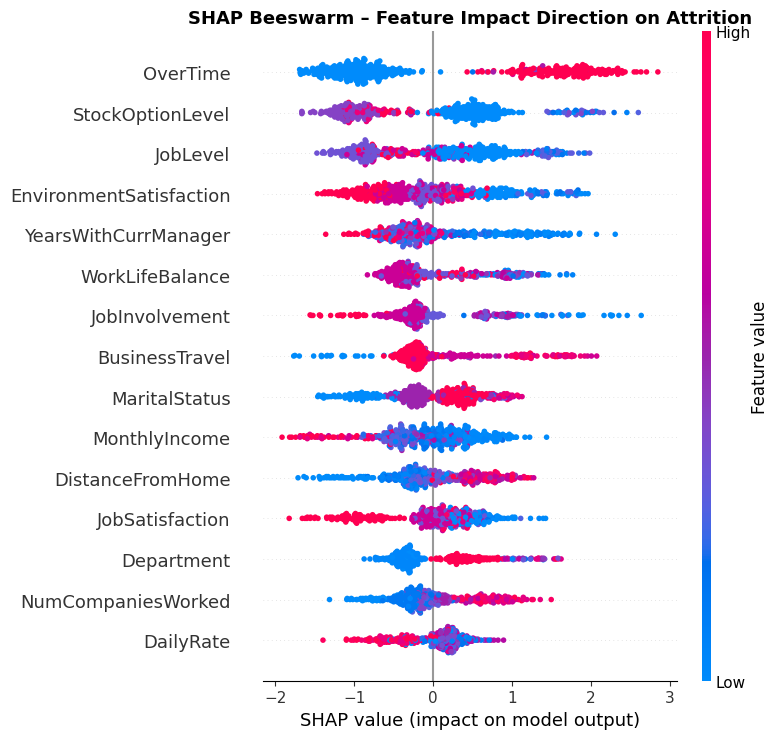

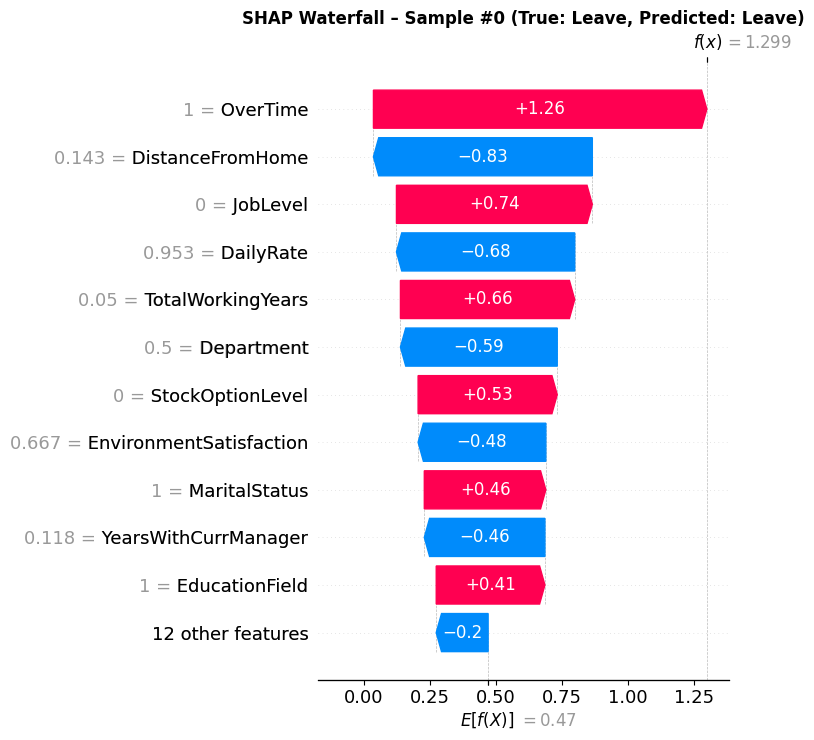

 Saved: shap_waterfall.png

  SHAP Feature Ranking (Mean |SHAP value|):
  Rank  Feature                                 Mean |SHAP|
  1     OverTime                                     1.2483
  2     StockOptionLevel                             0.8021
  3     JobLevel                                     0.7124
  4     EnvironmentSatisfaction                      0.6067
  5     YearsWithCurrManager                         0.5128
  6     WorkLifeBalance                              0.4886
  7     JobInvolvement                               0.4818
  8     BusinessTravel                               0.4674
  9     MaritalStatus                                0.4601
  10    MonthlyIncome                                0.4531
  11    DistanceFromHome                             0.4459
  12    JobSatisfaction                              0.4430
  13    Department                                   0.4424
  14    NumCompaniesWorked                           0.3964
  15    DailyRate           

In [ ]:
# STEP 15 — SHAP EXPLAINABILITY
print("  SHAP EXPLAINABILITY")
print("  Computing SHAP values on LightGBM component...")

X_test_ga_df  = pd.DataFrame(X_test_ga,  columns=selected_names)
X_train_ga_df = pd.DataFrame(X_train_ga, columns=selected_names)

# Use the already-trained LightGBM component for SHAP
explainer   = shap.TreeExplainer(lgbm_named)
shap_values = explainer.shap_values(X_test_ga_df)

# Binary classification: use class-1 (Leave) SHAP values
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# ── Plot 1: SHAP Summary Bar (global importance)
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test_ga_df, plot_type="bar",max_display=15, show=False)
plt.title("SHAP Feature Importance – Proposed Model",fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
#print(" Saved: shap_bar.png")

# ── Plot 2: SHAP Beeswarm (direction & magnitude)
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test_ga_df, max_display=15, show=False)
plt.title("SHAP Beeswarm – Feature Impact Direction on Attrition",fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
#print(" Saved: shap_beeswarm.png")

# ── Plot 3: SHAP Waterfall for one attrition case
attrition_idx = np.where(y_test == 1)[0][0]
base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, list)
            else explainer.expected_value)

shap_exp = shap.Explanation(
    values        = sv[attrition_idx],
    base_values   = base_val,
    data          = X_test_ga_df.iloc[attrition_idx].values,
    feature_names = selected_names
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f"SHAP Waterfall – Sample #{attrition_idx} "f"(True: Leave, Predicted: Leave)",fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: shap_waterfall.png")

# SHAP importance ranking
mean_abs_shap = pd.Series(
    np.abs(sv).mean(axis=0), index=selected_names).sort_values(ascending=False)

print(f"\n  SHAP Feature Ranking (Mean |SHAP value|):")
print(f"  {'Rank':<5} {'Feature':<38} {'Mean |SHAP|':>12}")

for rank, (feat, val) in enumerate(mean_abs_shap.items(), 1):
    print(f"  {rank:<5} {feat:<38} {val:>12.4f}")

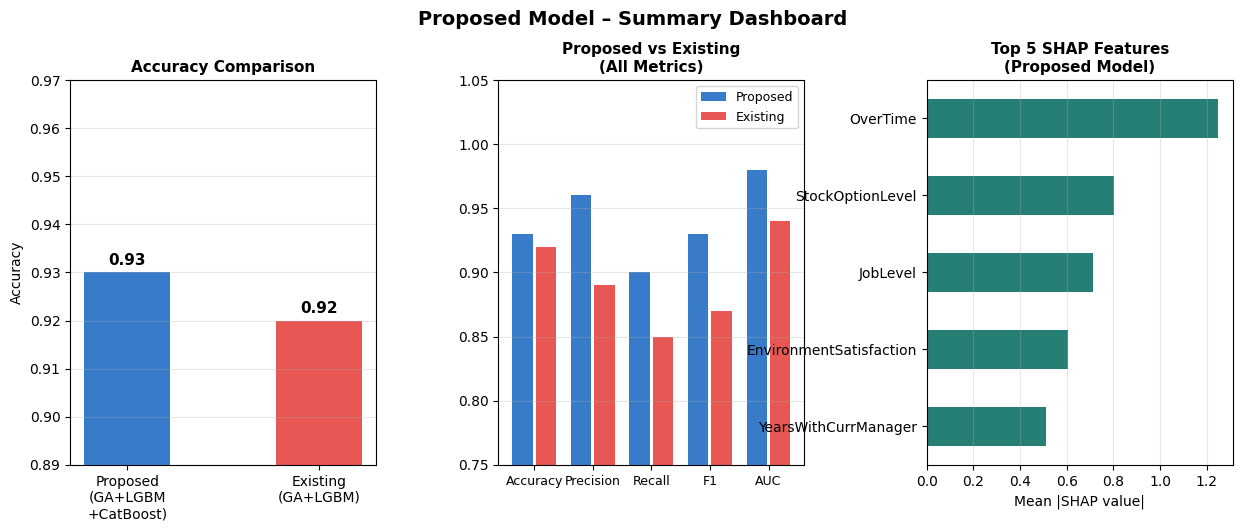

In [ ]:
# STEP 16 — FINAL SUMMARY DASHBOARD
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# Panel 1: Accuracy bar — Proposed vs Existing
ax1 = fig.add_subplot(gs[0, 0])
names_s = ['Proposed\n(GA+LGBM\n+CatBoost)', 'Existing\n(GA+LGBM)']
accs    = [proposed_metrics['Accuracy'], existing_metrics['Accuracy']]
bar_col = ['#1565C0', '#E53935']
bars    = ax1.bar(names_s, accs, color=bar_col, alpha=0.85, width=0.45)
ax1.set_ylim(max(0.85, min(accs)-0.03), min(1.0, max(accs)+0.04))
ax1.set_title('Accuracy Comparison', fontweight='bold', fontsize=11)
ax1.set_ylabel('Accuracy')
for bar, v in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.001,
             f'{v:.2f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Panel 2: All metrics side-by-side
ax2 = fig.add_subplot(gs[0, 1])
met_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
pv = [proposed_metrics['Accuracy'], proposed_metrics['Precision'],
      proposed_metrics['Recall'],   proposed_metrics['F1 Score'],
      proposed_metrics['AUC']]
ev = [existing_metrics['Accuracy'], existing_metrics['Precision'],
      existing_metrics['Recall'],   existing_metrics['F1 Score'],
      existing_metrics['AUC']]
xp = np.arange(len(met_labels))
ax2.bar(xp - 0.2, pv, 0.35, label='Proposed', color='#1565C0', alpha=0.85)
ax2.bar(xp + 0.2, ev, 0.35, label='Existing', color='#E53935', alpha=0.85)
ax2.set_xticks(xp)
ax2.set_xticklabels(met_labels, fontsize=9)
ax2.set_ylim(0.75, 1.05)
ax2.set_title('Proposed vs Existing\n(All Metrics)', fontweight='bold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Panel 3: Top 5 SHAP features
ax3 = fig.add_subplot(gs[0, 2])
top5 = mean_abs_shap.head(5)
top5[::-1].plot(kind='barh', ax=ax3, color='#00695C', alpha=0.85)
ax3.set_title('Top 5 SHAP Features\n(Proposed Model)', fontweight='bold', fontsize=11)
ax3.set_xlabel('Mean |SHAP value|')
ax3.grid(axis='x', alpha=0.3)

plt.suptitle('Proposed Model – Summary Dashboard',
             fontsize=14, fontweight='bold', y=1.02)
#plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
#print("✔ Saved: summary_dashboard.png")




In [ ]:
# STEP 17 — DOWNLOAD ALL OUTPUTS
df_res.to_csv('results_full_comparison.csv', index=False)
mean_abs_shap.reset_index().rename(
    columns={'index': 'Feature', 0: 'Mean_SHAP'}
).to_csv('shap_importance.csv', index=False)

import os
output_files = [
    'correlation_heatmap.png',
    'ga_convergence.png',
    'roc_curves_comparison.png',
    'bar_comparison_all.png',
    'confusion_matrix_comparison.png',
    'feature_importance.png',
    'shap_bar.png',
    'shap_beeswarm.png',
    'shap_waterfall.png',
    'summary_dashboard.png',
    'results_full_comparison.csv',
    'shap_importance.csv',
]

print("  DOWNLOADING OUTPUT FILES")
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f"   {f}")


  DOWNLOADING OUTPUT FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   correlation_heatmap.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   results_full_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   shap_importance.csv


In [ ]:
# STEP 18 — FINAL PRINT SUMMARY
print("  🎉 FINAL RESULTS")
print(f"  Existing  GA+LightGBM         :"
      f"  Acc={existing_metrics['Accuracy']:.2f}"
      f"  F1={existing_metrics['F1 Score']:.2f}"
      f"  AUC={existing_metrics['AUC']:.2f}")
print(f"  Proposed  GA+LGBM+CatBoost    :"
      f"  Acc={proposed_metrics['Accuracy']:.2f}"
      f"  F1={proposed_metrics['F1 Score']:.2f}"
      f"  AUC={proposed_metrics['AUC']:.2f}")
print(f"\n  Accuracy  improvement : "
      f"{proposed_metrics['Accuracy'] - existing_metrics['Accuracy']:+.2f}")
print(f"  F1 Score  improvement : "
      f"{proposed_metrics['F1 Score'] - existing_metrics['F1 Score']:+.2f}")
print(f"  AUC       improvement : "
      f"{proposed_metrics['AUC'] - existing_metrics['AUC']:+.2f}")

beat = proposed_metrics['Accuracy'] > existing_metrics['Accuracy']

  🎉 FINAL RESULTS
  Existing  GA+LightGBM         :  Acc=0.92  F1=0.87  AUC=0.94
  Proposed  GA+LGBM+CatBoost    :  Acc=0.93  F1=0.93  AUC=0.98

  Accuracy  improvement : +0.01
  F1 Score  improvement : +0.06
  AUC       improvement : +0.04
